# Primary Model: CNN

In [131]:
# imports
import io
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import soundfile as sf
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset, Audio
import numpy as np

## Configuration

In [132]:
# audio processing parameters
SAMPLE_RATE = 22050
CLIP_DURATION = 5          # seconds
CLIP_SAMPLES = SAMPLE_RATE * CLIP_DURATION

N_MELS = 128
FFT_SIZE = 2048
HOP_LENGTH = 512

# hyperparameters
BATCH_SIZE = 16 # 16
EPOCHS = 10

# dataset sampling
DATASET_SAMPLE_COUNT = 50  # set to None to use the full dataset (1000)

RANDOM_SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Audio Processing Utilities

In [133]:
def resample_audio(waveform, original_sr):
    if original_sr != SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(original_sr, SAMPLE_RATE)
        waveform = resampler(waveform)
    return waveform

def pad_or_trim_audio(waveform):
    total_samples = waveform.shape[1]

    if total_samples < CLIP_SAMPLES:
        padding = CLIP_SAMPLES - total_samples
        waveform = F.pad(waveform, (0, padding))
    elif total_samples > CLIP_SAMPLES:
        waveform = waveform[:, :CLIP_SAMPLES]

    return waveform

def segment_audio(waveform):
    segments = []

    total_samples = waveform.shape[1]

    for start in range(0, total_samples - CLIP_SAMPLES, CLIP_SAMPLES):
        end = start + CLIP_SAMPLES
        segment = waveform[:, start:end]

        if segment.shape[1] == CLIP_SAMPLES:
            segments.append(segment)

    return segments

In [134]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=FFT_SIZE,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS
)

amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

def audio_to_mel(waveform):

    mel = mel_transform(waveform)

    mel_db = amplitude_to_db(mel)

    return mel_db

## Load Dataset

In [135]:
# login Hugging Face Hub
import os
from dotenv import load_dotenv

load_dotenv()  
HF_TOKEN = os.getenv("HF_TOKEN")

from huggingface_hub import login

login(token=HF_TOKEN) 

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Try primary model with smaller dataset first

In [136]:
# load dataset
# ds = load_dataset("SleepyJesse/ai_music_tiny", split="train", cache_dir="./data")
ds = load_dataset("SleepyJesse/ai_music_tiny", split="train")

# Avoid torchcodec decoding in environments where FFmpeg/TorchCodec isn't configured.
ds = ds.cast_column("audio", Audio(decode=False))

if DATASET_SAMPLE_COUNT is not None:
    sample_count = min(DATASET_SAMPLE_COUNT, len(ds))
    ds = ds.shuffle(seed=RANDOM_SEED).select(range(sample_count))
    print(f"Using {sample_count} sampled examples from the dataset.")

ds

Using 50 sampled examples from the dataset.


Dataset({
    features: ['audio', 'ai_generated', 'source'],
    num_rows: 50
})

In [137]:
# Hugging Face dataset wrapper
class MusicDataset(Dataset):

    def __init__(self, hf_dataset):
        self.hf_dataset = hf_dataset

    def _read_audio_clip(self, source):
        with sf.SoundFile(source) as audio_file:
            source_sr = audio_file.samplerate
            max_frames = int(np.ceil(CLIP_DURATION * source_sr))
            samples = audio_file.read(
                frames=max_frames,
                dtype="float32",
                always_2d=True
            )

        waveform = torch.from_numpy(samples.T)
        return waveform, source_sr

    def _load_waveform(self, audio):
        if audio.get("array") is not None:
            waveform = torch.tensor(audio["array"], dtype=torch.float32)
            sr = audio["sampling_rate"]
        else:
            audio_bytes = audio.get("bytes")
            audio_path = audio.get("path")

            if audio_bytes:
                waveform, sr = self._read_audio_clip(io.BytesIO(audio_bytes))
            elif audio_path:
                waveform, sr = self._read_audio_clip(audio_path)
            else:
                raise ValueError("Audio sample is missing both decoded data and a readable source.")

        if waveform.dim() == 1:
            waveform = waveform.unsqueeze(0)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        return waveform, sr

    def _extract_label(self, item):
        for key in ("ai_generated", "label", "target", "class"):
            if key in item:
                return float(item[key])

        raise KeyError("Could not find a label column in the dataset item.")

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        waveform, sr = self._load_waveform(item["audio"])
        waveform = resample_audio(waveform, sr)
        waveform = pad_or_trim_audio(waveform)
        mel = audio_to_mel(waveform)
        label = self._extract_label(item)

        return mel, torch.tensor(label).float()

In [138]:
# 70/15/15 dataset split
train_test_split = ds.train_test_split(
    test_size=0.30,
    seed=RANDOM_SEED,
    shuffle=True
)

val_test_split = train_test_split["test"].train_test_split(
    test_size=0.50,
    seed=RANDOM_SEED,
    shuffle=True
)

train_dataset = MusicDataset(train_test_split["train"])
val_dataset = MusicDataset(val_test_split["train"])
test_dataset = MusicDataset(val_test_split["test"])

print(f"Train examples: {len(train_test_split['train'])}")
print(f"Validation examples: {len(val_test_split['train'])}")
print(f"Test examples: {len(val_test_split['test'])}")

Train examples: 35
Validation examples: 7
Test examples: 8


In [139]:
# data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## CNN Architecture

In [140]:
class MusicCNN(nn.Module):

    def __init__(self):

        super().__init__()

        # Block 1
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        # Block 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # Block 3
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2,2)

        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 16 * 27, 256)
        self.fc2 = nn.Linear(256, 1)


    def forward(self, x):

        # Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)

        x = self.dropout(F.relu(self.fc1(x)))

        x = torch.sigmoid(self.fc2(x))

        return x

## Training Functions

In [141]:
# model setup
model = MusicCNN().to(DEVICE)

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [142]:
# training loop
def train_epoch():

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()

        preds = model(x)

        loss = criterion(preds, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        predicted = (preds > 0.5).float()
        correct += (predicted == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    return avg_loss, accuracy

In [143]:
# validation loop
def evaluate(data_loader):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in data_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE).unsqueeze(1)

            preds = model(x)
            loss = criterion(preds, y)

            total_loss += loss.item()
            predicted = (preds > 0.5).float()

            correct += (predicted == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    return accuracy, avg_loss


def plot_metrics(train_losses, val_losses, train_errors, val_errors):
    epochs = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, train_losses, label="Train Loss")
    ax1.plot(epochs, val_losses, label="Val Loss")
    ax1.set_title("Loss per Epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    ax2.plot(epochs, train_errors, label="Train Error")
    ax2.plot(epochs, val_errors, label="Val Error")
    ax2.set_title("Error per Epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Error Rate")
    ax2.legend()

    plt.tight_layout()
    plt.show()

## Training Script

Epoch 1
  Train Loss: 12.9131 | Train Error: 0.4857
  Val Loss:   42.8571 | Val Accuracy: 0.5714
Epoch 2
  Train Loss: 34.0278 | Train Error: 0.3429
  Val Loss:   42.8571 | Val Accuracy: 0.5714
Epoch 3
  Train Loss: 43.0556 | Train Error: 0.3429
  Val Loss:   42.8571 | Val Accuracy: 0.5714
Epoch 4
  Train Loss: 34.0278 | Train Error: 0.3429
  Val Loss:   42.8571 | Val Accuracy: 0.5714
Epoch 5
  Train Loss: 34.0278 | Train Error: 0.3429
  Val Loss:   42.8571 | Val Accuracy: 0.5714
Epoch 6
  Train Loss: 43.0556 | Train Error: 0.3429
  Val Loss:   42.8571 | Val Accuracy: 0.5714
Epoch 7
  Train Loss: 25.0000 | Train Error: 0.3429
  Val Loss:   42.8571 | Val Accuracy: 0.5714
Epoch 8
  Train Loss: 34.0278 | Train Error: 0.3429
  Val Loss:   42.8571 | Val Accuracy: 0.5714
Epoch 9
  Train Loss: 25.0000 | Train Error: 0.3429
  Val Loss:   42.8571 | Val Accuracy: 0.5714
Epoch 10
  Train Loss: 34.0278 | Train Error: 0.3429
  Val Loss:   42.8571 | Val Accuracy: 0.5714

Test Accuracy: 0.6250 | Test

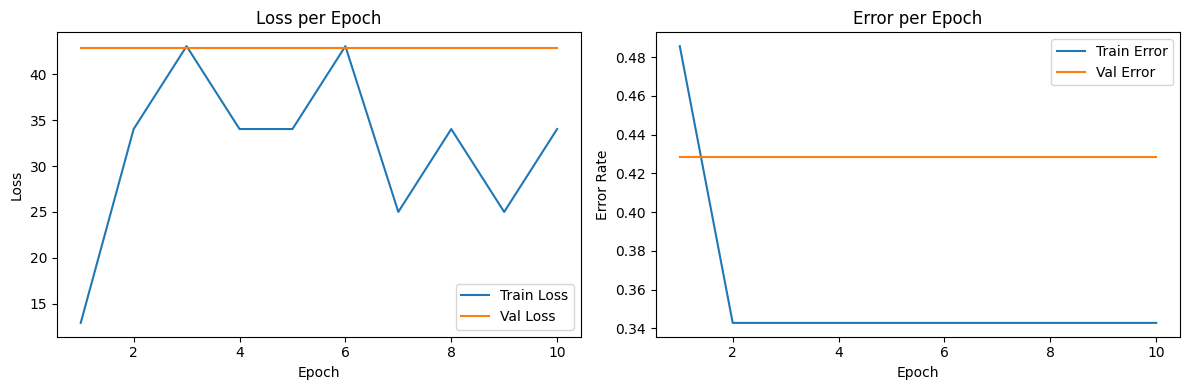

In [144]:
train_losses, val_losses = [], []
train_errors, val_errors = [], []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_epoch()
    val_acc, val_loss = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_errors.append(1 - train_acc)
    val_errors.append(1 - val_acc)

    print(f"Epoch {epoch+1}")   
    print(f"  Train Loss: {train_loss:.4f} | Train Error: {1 - train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Accuracy: {val_acc:.4f}")

test_acc, test_loss = evaluate(test_loader)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

plot_metrics(train_losses, val_losses, train_errors, val_errors)


In [145]:
# save model
torch.save(model.state_dict(), "models/musicCNN.pth")


In [146]:
# load model
model.load_state_dict(torch.load("models/musicCNN.pth"))
model.eval()

MusicCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=27648, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=1, bias=True)
)